# Import Library

In [1]:
# Import Library:

# Import library dasar untuk manipulasi file dan data
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE" # untuk menghindari error pada beberapa sistem dan memakai dua dua versi library OpenMP 
import cv2
import shutil #untuk mengatur file dan folder (seperti menghapus, memindah, menyalin, dll
# Import library untuk numerik dan visualisasi
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
# Import library PyTorch (untuk cek apakah environment sudah siap)
import torch
import torchvision


from collections import defaultdict, Counter
from PIL import Image
from pathlib import Path


def seed_everything(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# Konfigurasi visual
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print(f" PyTorch Version: {torch.__version__}")
print(f" Torchvision Version: {torchvision.__version__}")
print(f" CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU Device: {torch.cuda.get_device_name(0)}")


 PyTorch Version: 2.7.1+cu118
 Torchvision Version: 0.22.1+cu118
 CUDA Available: True
   GPU Device: NVIDIA GeForce RTX 3060


# Konfigurasi Path Dataset

In [2]:
# Konfigurasi Path Dataset

import os

# =========================================================
# KONFIGURASI PATH SESUAI STRUKTUR ASLI DATASET_MRL
# =========================================================

# Path utama dataset (parent folder)
DATASET_ROOT = r"C:\kuliah-sementara\SKRIPSI\Dataset_nthuddd2"

# Nama kelas sesuai dengan nama folder asli kamu
CLASS_NAMES = ["drowsy", "notdrowsy"] 

print("="*60)
print(f"{'PEMERIKSAAN DATASET MRL':^60}")
print("="*60)

total_all_images = 0

# Cek apakah folder utama ada
if os.path.exists(DATASET_ROOT):
    print(f"[OK] Folder Utama Ditemukan: {DATASET_ROOT}\n")
    
    for class_name in CLASS_NAMES:
        class_path = os.path.join(DATASET_ROOT, class_name)
        
        if os.path.exists(class_path):
            # Mengambil daftar file (hanya gambar .png, .jpg, .jpeg)
            images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            count = len(images)
            total_all_images += count
            
            print(f"├─ Kelas '{class_name}'")
            print(f"│  ├─ Status      : DITEMUKAN")
            print(f"│  ├─ Lokasi      : {class_path}")
            print(f"│  └─ Jumlah Data : {count} gambar")
            print(f"│")
        else:
            print(f"├─ Kelas '{class_name}' : [TIDAK DITEMUKAN!]")
            print(f"│  └─ Pastikan nama folder '{class_name}' sudah benar.")
else:
    print(f"[ERROR] Folder Utama TIDAK DITEMUKAN: {DATASET_ROOT}")

print("="*60)
print(f" TOTAL KESELURUHAN DATA: {total_all_images} Gambar")
print("="*60)

                  PEMERIKSAAN DATASET MRL                   
[OK] Folder Utama Ditemukan: C:\kuliah-sementara\SKRIPSI\Dataset_nthuddd2

├─ Kelas 'drowsy'
│  ├─ Status      : DITEMUKAN
│  ├─ Lokasi      : C:\kuliah-sementara\SKRIPSI\Dataset_nthuddd2\drowsy
│  └─ Jumlah Data : 36034 gambar
│
├─ Kelas 'notdrowsy'
│  ├─ Status      : DITEMUKAN
│  ├─ Lokasi      : C:\kuliah-sementara\SKRIPSI\Dataset_nthuddd2\notdrowsy
│  └─ Jumlah Data : 30491 gambar
│
 TOTAL KESELURUHAN DATA: 66525 Gambar


# MENGHITUNG STATISTIK PIXEL


[INFO] MENGHITUNG STATISTIK PIXEL (Sampling 5000 gambar/kelas)...
 ├─ Memproses 5000 gambar dari kelas 'drowsy'...


 ├─ Memproses 5000 gambar dari kelas 'notdrowsy'...


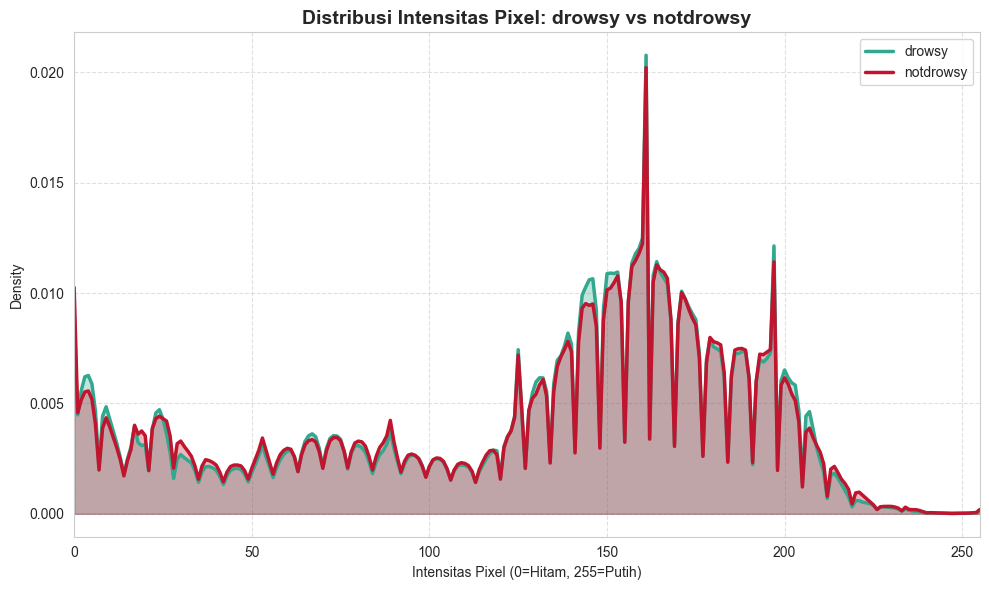

In [4]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ===========================
# KONFIGURASI PATH
# ===========================
def plot_pixel_intensity_distribution(base_dir, samples_per_class=5000):
    print(f"\n[INFO] MENGHITUNG STATISTIK PIXEL (Sampling {samples_per_class} gambar/kelas)...")
    
    # Histograms 0-255
    histograms = {name: np.zeros(256, dtype=np.float64) for name in CLASS_NAMES}
    total_pixels_per_class = {name: 0 for name in CLASS_NAMES}
    
    for class_name in CLASS_NAMES:
        class_path = os.path.join(base_dir, class_name)
        if not os.path.exists(class_path): 
            print(f" [!] Warning: Folder tidak ditemukan: {class_path}")
            continue
            
        all_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if len(all_files) == 0:
            print(f" [!] Warning: Folder kosong: {class_path}")
            continue
            
        # Sampling acak agar lebih efisien namun tetap representatif
        sample_size = min(len(all_files), samples_per_class)
        sample_files = np.random.choice(all_files, sample_size, replace=False)
        
        print(f" ├─ Memproses {sample_size} gambar dari kelas '{class_name}'...")
        
        for f in sample_files:
            try:
                img_path = os.path.join(class_path, f)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    # Menggunakan OpenCV calcHist (Sangat Cepat)
                    hist = cv2.calcHist([img], [0], None, [256], [0, 256])
                    histograms[class_name] += hist.flatten()
                    total_pixels_per_class[class_name] += img.size
            except Exception as e:
                continue

    # --- Plotting ---
    plt.figure(figsize=(10, 6))
    # Hijau untuk Open, Merah untuk Close (sesuai logika drowsy)
    colors = {'drowsy': '#32A88F', 'notdrowsy': '#C0152F'}
    
    for class_name in CLASS_NAMES:
        if total_pixels_per_class[class_name] > 0:
            # Normalisasi menjadi Density (PDF)
            pdf = histograms[class_name] / total_pixels_per_class[class_name]
            
            plt.plot(range(256), pdf, label=class_name, color=colors[class_name], linewidth=2.5)
            plt.fill_between(range(256), pdf, color=colors[class_name], alpha=0.3)
    
    plt.title("Distribusi Intensitas Pixel: drowsy vs notdrowsy", fontsize=14, fontweight='bold')
    plt.xlabel("Intensitas Pixel (0=Hitam, 255=Putih)")
    plt.ylabel("Density")
    plt.xlim([0, 255])
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# --- EKSEKUSI ---
# Menggunakan DATASET_ROOT karena belum ada folder train/val/test
plot_pixel_intensity_distribution(DATASET_ROOT)


# Distribusi Subjek(drawsy vs notdrawsy)


[INFO] Mencari di: C:\kuliah-sementara\SKRIPSI\Dataset_nthuddd2
 [OK] Folder drowsy berisi 36034 item.
 [OK] Folder notdrowsy berisi 30491 item.
 > drowsy: Terbanyak 005 (13087 file)
 > notdrowsy: Terbanyak 001 (9432 file)


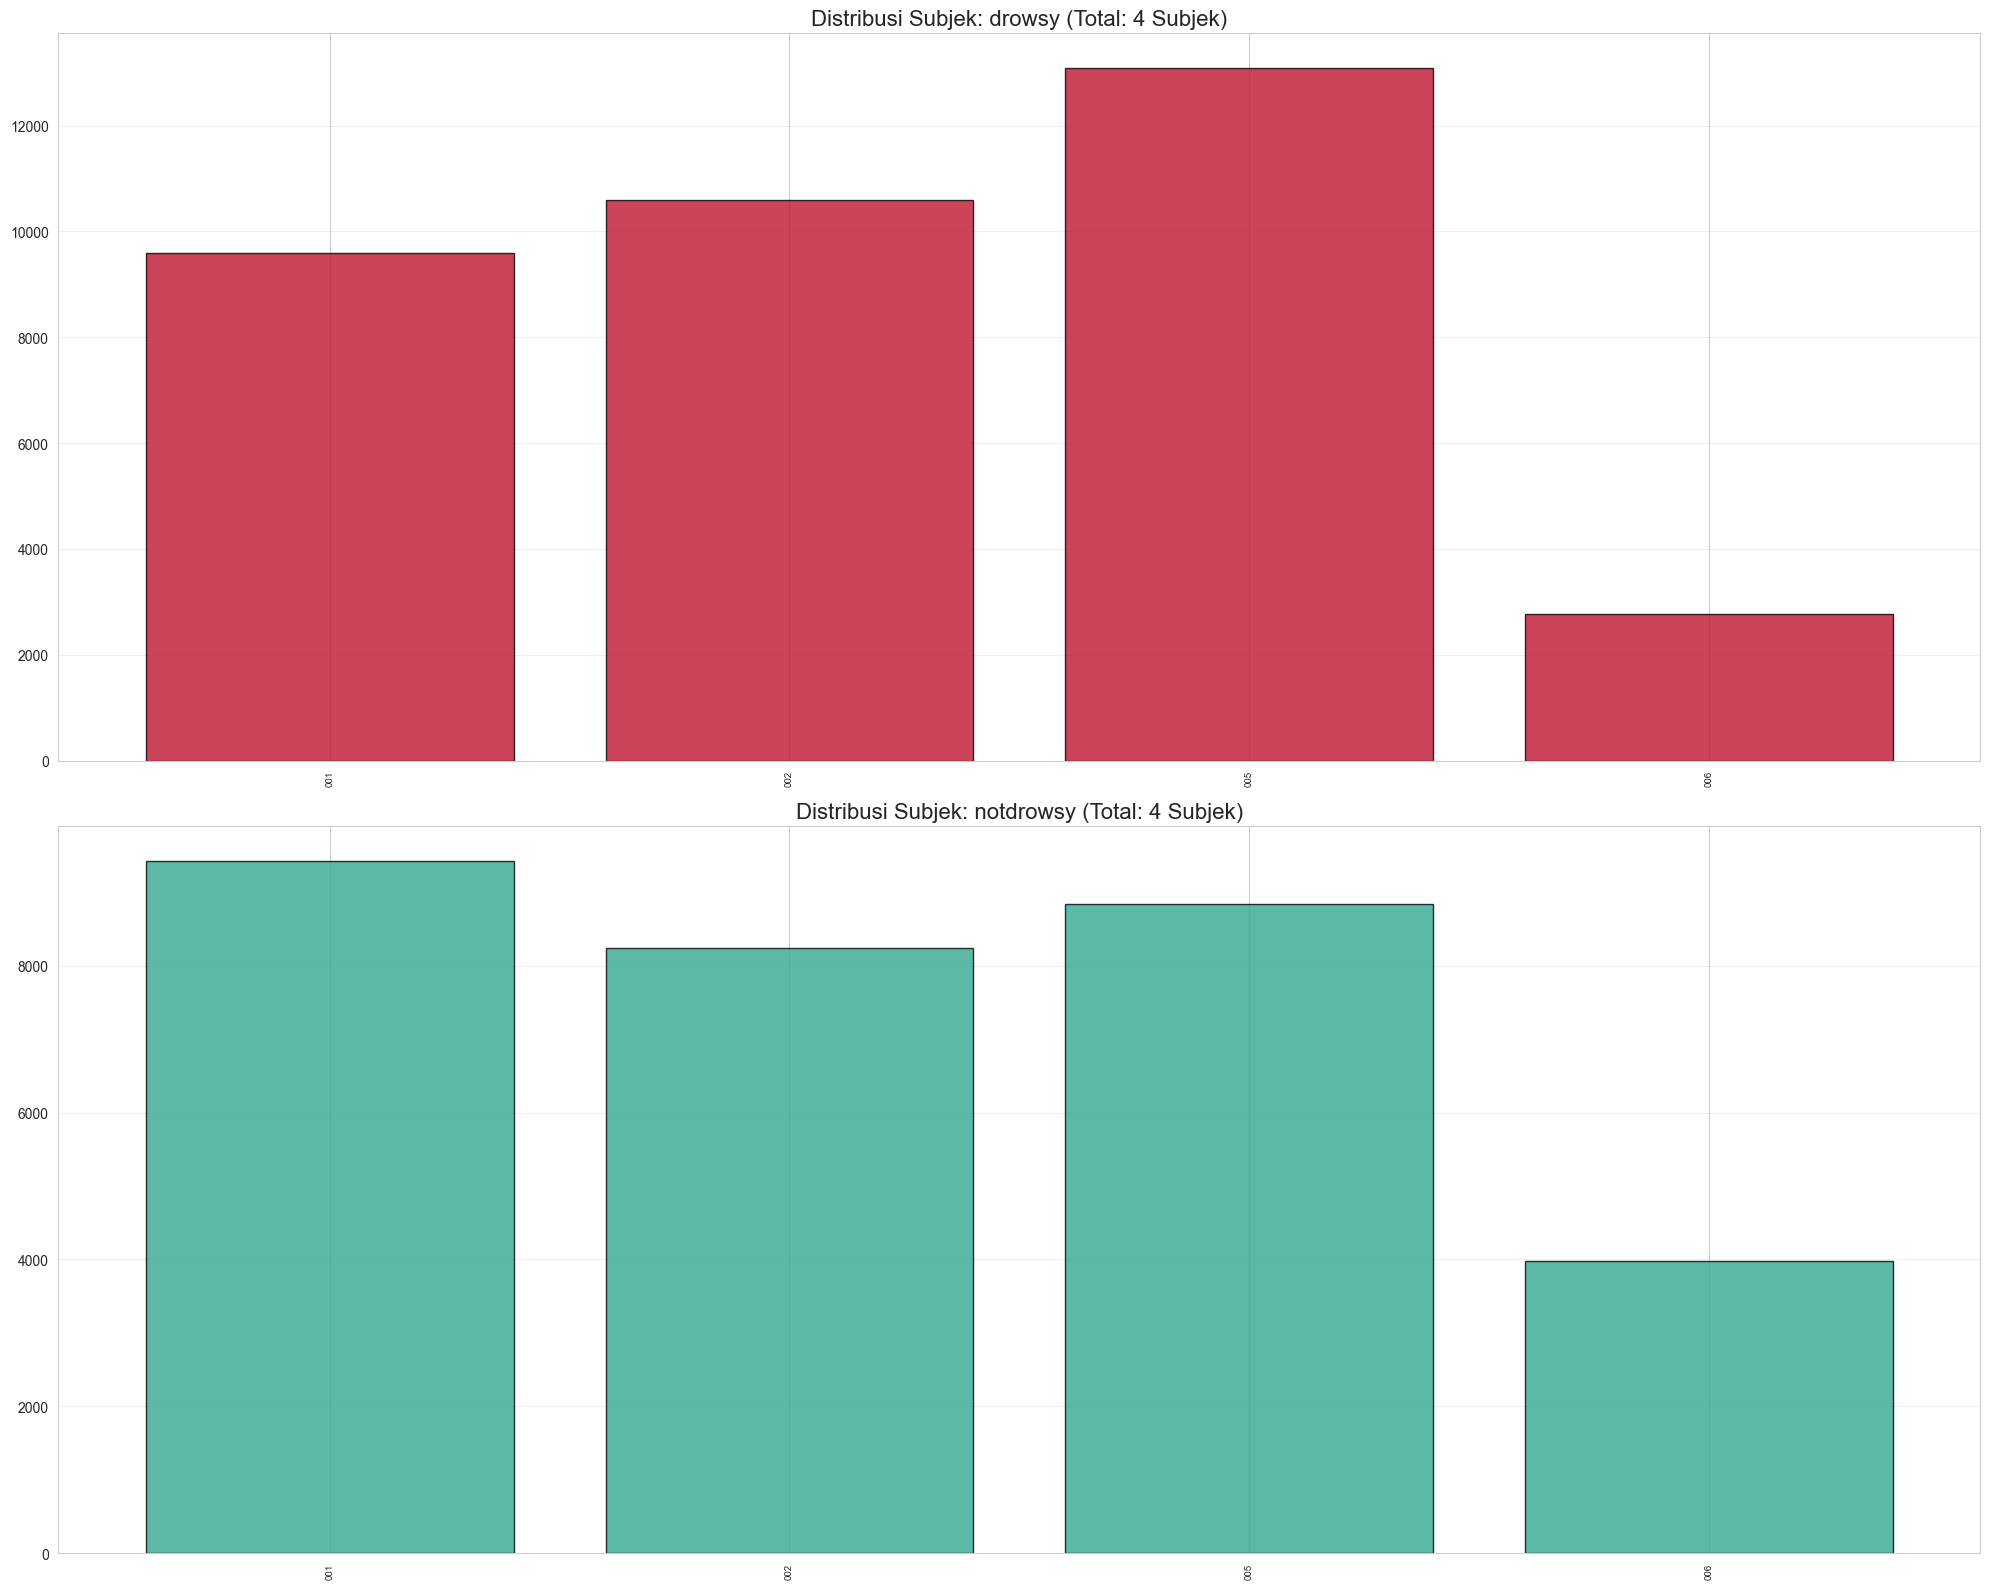

In [5]:

import os
import matplotlib.pyplot as plt
from collections import Counter

# ===========================
# KONFIGURASI PATH (PASTIKAN RAW STRING 'r')
# ===========================

def analyze_nthud_subjects(base_dir):
    print(f"\n[INFO] Mencari di: {base_dir}")
    
    # Dictionary untuk menyimpan Counter per kelas
    stats = {name: Counter() for name in CLASS_NAMES}

    # Scanning file
    for class_name in CLASS_NAMES:
        class_path = os.path.join(base_dir, class_name)
        
        if not os.path.exists(class_path):
            print(f" [!] Folder TIDAK DITEMUKAN: {class_path}")
            continue
            
        # Ambil SEMUA file tanpa filter ketat dulu untuk cek isi
        all_items = os.listdir(class_path)
        print(f" [OK] Folder {class_name} berisi {len(all_items)} item.")
        
        for f in all_items:
            # Kita ambil yang mengandung '_' karena format MRL selalu pakai underscore
            if "_" in f:
                parts = f.split('_')
                subject_id = parts[0] # Mengambil 's0001'
                stats[class_name][subject_id] += 1

    # --- Visualisasi ---
    # Jika kedua kelas kosong, jangan lanjut ke plotting
    if sum(len(c) for c in stats.values()) == 0:
        print("\n [!!!] ERROR: Tidak ada data subjek yang berhasil terbaca.")
        print(" Pastikan file gambar ada langsung di dalam folder drowsy dan notdrowsy.")
        return

    fig, axes = plt.subplots(2, 1, figsize=(20, 16))
    colors = ['#C0152F', '#32A88F']

    for i, class_name in enumerate(CLASS_NAMES):
        if not stats[class_name]:
            print(f" [!] Skip plotting {class_name} karena kosong.")
            continue
            
        # Urutkan berdasarkan ID Subjek
        sorted_data = sorted(stats[class_name].items()) 
        subjects, counts = zip(*sorted_data)
        
        bars = axes[i].bar(subjects, counts, color=colors[i], edgecolor='black', alpha=0.8)
        axes[i].set_title(f"Distribusi Subjek: {class_name} (Total: {len(subjects)} Subjek)", fontsize=16)
        axes[i].tick_params(axis='x', rotation=90, labelsize=7)
        axes[i].grid(axis='y', alpha=0.3)
        
        # Print Statistik Ringkas
        top_s = max(stats[class_name], key=stats[class_name].get)
        print(f" > {class_name}: Terbanyak {top_s} ({stats[class_name][top_s]} file)")

    plt.tight_layout()
    plt.show()

# Jalankan
analyze_nthud_subjects(DATASET_ROOT)

# Perbandingan Distribusi Keseluruhan


[INFO] Mencari di: C:\kuliah-sementara\SKRIPSI\Dataset_nthuddd2


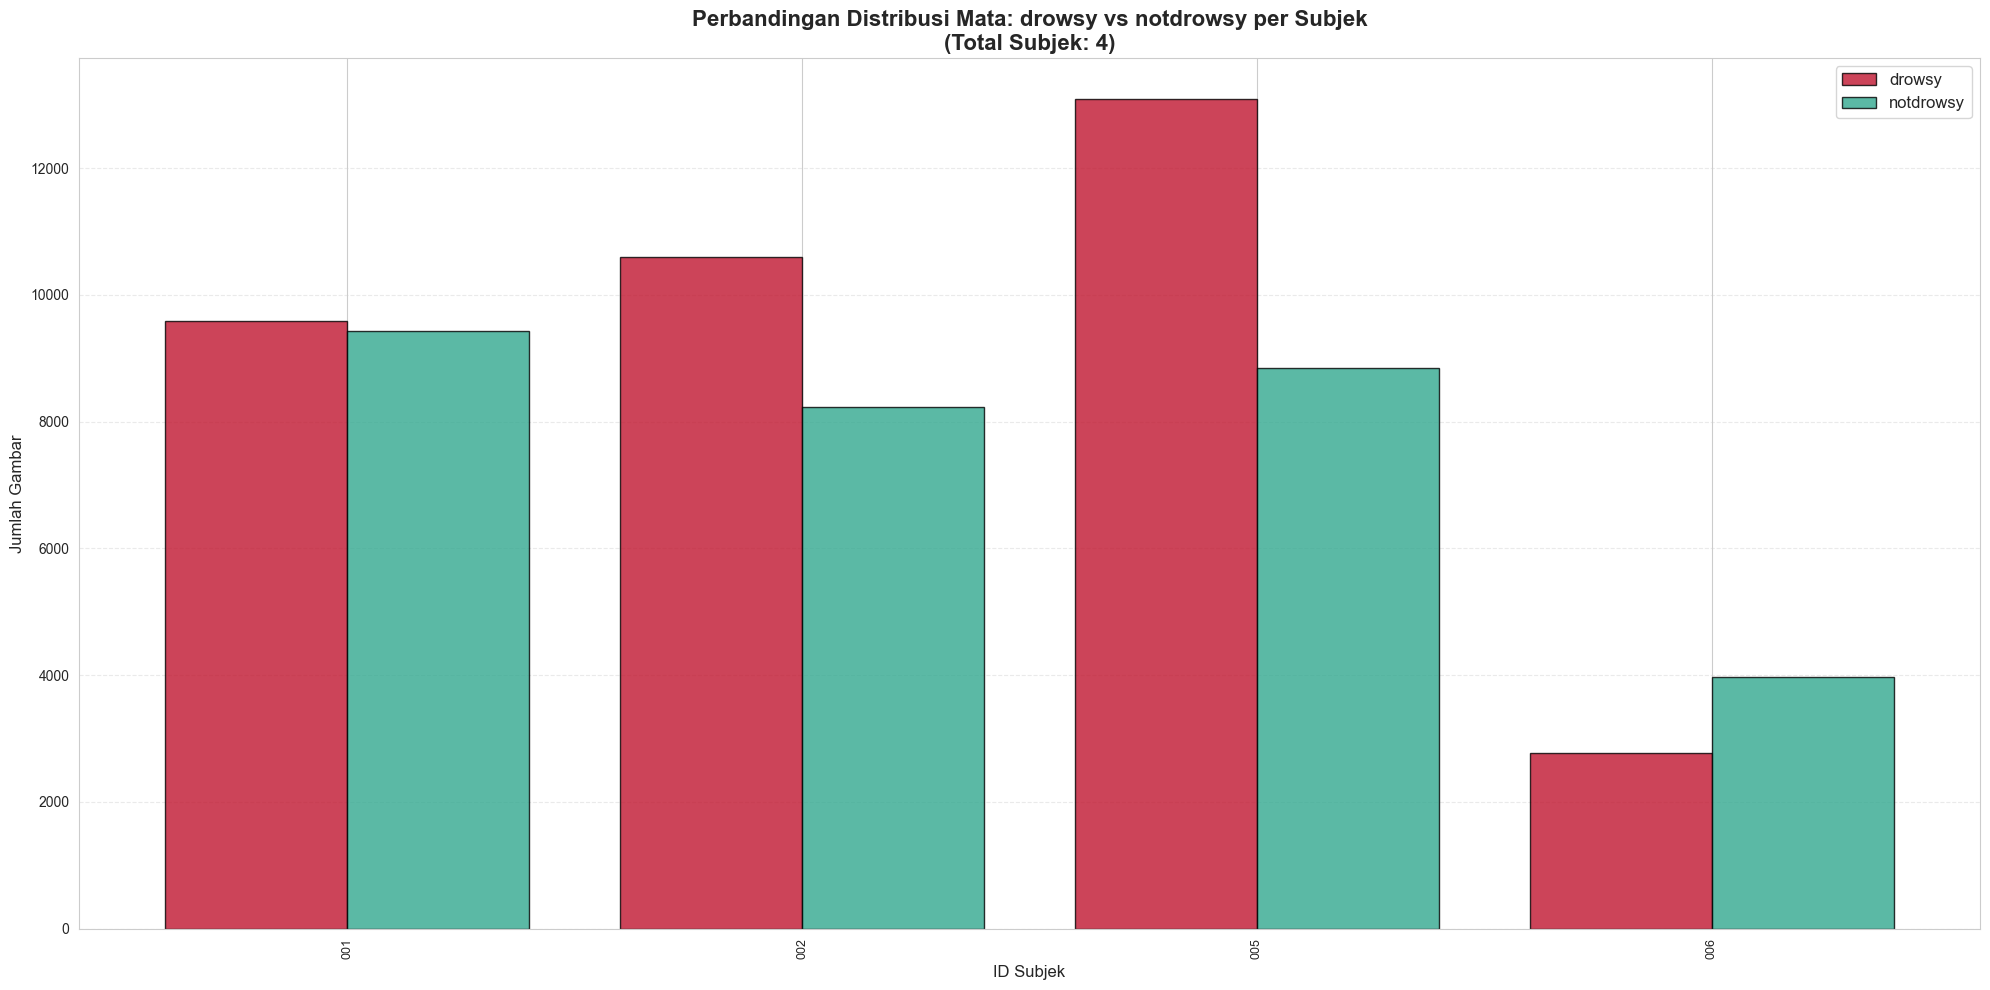


 STATISTIK TOTAL:
 > Total drowsy: 36034
 > Total notdrowsy : 30491
 > Imbalance Ratio : 1.18x


In [7]:

import os
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# ===========================
# KONFIGURASI PATH
# ===========================

def analyze_nthud_combined(base_dir):
    print(f"\n[INFO] Mencari di: {base_dir}")
    
    stats = {name: Counter() for name in CLASS_NAMES}
    all_subjects = set()

    for class_name in CLASS_NAMES:
        class_path = os.path.join(base_dir, class_name)
        if not os.path.exists(class_path):
            print(f" [!] Folder TIDAK DITEMUKAN: {class_path}")
            continue
            
        all_items = os.listdir(class_path)
        for f in all_items:
            if "_" in f:
                subject_id = f.split('_')[0]
                stats[class_name][subject_id] += 1
                all_subjects.add(subject_id)

    if not all_subjects:
        print("\n [!!!] ERROR: Tidak ada data subjek terbaca.")
        return

    sorted_subjects = sorted(list(all_subjects))
    drowsy_counts = [stats["drowsy"][s] for s in sorted_subjects]
    notdrowsy_counts = [stats["notdrowsy"][s] for s in sorted_subjects]

    # --- Visualisasi ---
    x = np.arange(len(sorted_subjects))
    width = 0.4 

    plt.figure(figsize=(20, 10))
    
    plt.bar(x - width/2, drowsy_counts, width, label='drowsy', color='#C0152F', edgecolor='black', alpha=0.8)
    plt.bar(x + width/2, notdrowsy_counts, width, label='notdrowsy', color='#32A88F', edgecolor='black', alpha=0.8)

    plt.title(f"Perbandingan Distribusi Mata: drowsy vs notdrowsy per Subjek\n(Total Subjek: {len(sorted_subjects)})", 
              fontsize=16, fontweight='bold')
    plt.xlabel("ID Subjek", fontsize=12)
    plt.ylabel("Jumlah Gambar", fontsize=12)
    
    # PERBAIKAN DI SINI:
    plt.xticks(x, sorted_subjects, rotation=90) # Hapus labelsize dari sini
    plt.tick_params(axis='x', labelsize=9)     # Pindahkan ke sini
    
    plt.legend(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    plt.show()

    # Statistik Ringkas
    total_drowsy = sum(drowsy_counts)
    total_notdrowsy = sum(notdrowsy_counts)
    print(f"\n STATISTIK TOTAL:")
    print(f" > Total drowsy: {total_drowsy}")
    print(f" > Total notdrowsy : {total_notdrowsy}")
    if min(total_drowsy, total_notdrowsy) > 0:
        print(f" > Imbalance Ratio : {max(total_drowsy, total_notdrowsy) / min(total_drowsy, total_notdrowsy):.2f}x")

# Jalankan
analyze_nthud_combined(DATASET_ROOT)

# Menampilkan Keseluruhan Subject yang akan Di Pilih Di Pembagian Data

        HASIL RE-BALANCING DATASET (TARGET 80:10:10)        
TRAIN |  2 Subjek |  40949 Gbr | 61.55%
VAL   |  1 Subjek |  18833 Gbr | 28.31%
TEST  |  1 Subjek |   6743 Gbr | 10.14%
------------------------------------------------------------

>>> ID SUBJEK UNTUK SCRIPT SPLIT:
VAL_IDS  = ['002']
TEST_IDS = ['006']


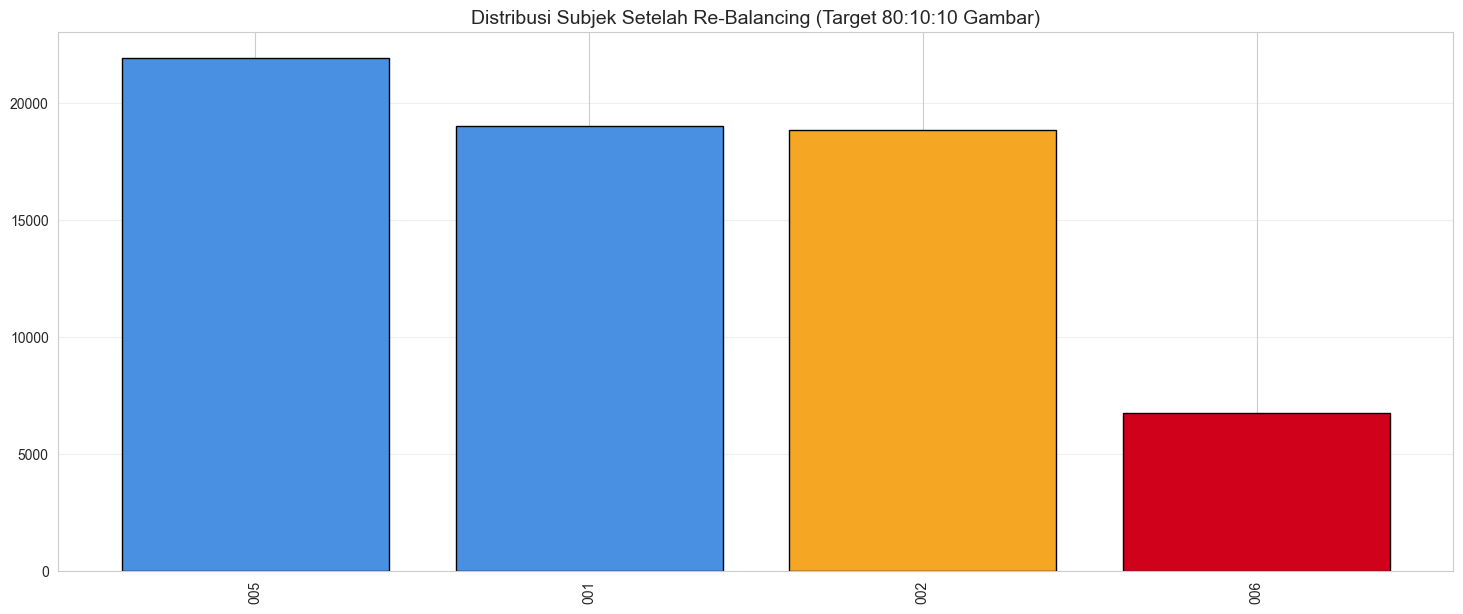

In [8]:

import os
import matplotlib.pyplot as plt
from collections import Counter

# ===========================
# KONFIGURASI PATH
# ===========================

def audit_balanced_split(base_dir):
    # 1. Hitung total per subjek
    total_per_subject = Counter()
    for class_name in CLASS_NAMES:
        class_path = os.path.join(base_dir, class_name)
        if os.path.exists(class_path):
            for f in os.listdir(class_path):
                if "_" in f:
                    subject_id = f.split('_')[0]
                    total_per_subject[subject_id] += 1

    if not total_per_subject:
        print(" [!] Data tidak ditemukan.")
        return

    # Urutkan dari yang terbanyak
    sorted_s = total_per_subject.most_common()
    total_all = sum(total_per_subject.values())
    
    # Target 10% untuk Val dan 10% untuk Test
    target_val = total_all * 0.10
    target_test = total_all * 0.10

    train_list, val_list, test_list = [], [], []
    current_val_sum, current_test_sum = 0, 0

    # STRATEGI: Ambil dari bawah (subjek kecil) untuk Test & Val sampai memenuhi target 10%
    # Sisanya masuk ke Train. Ini memastikan Test & Val punya jumlah gambar yang cukup.
    
    reversed_s = sorted_s[::-1] # Balik urutan dari yang terkecil
    
    temp_idx = 0
    # Isi Test dulu sampai mendekati 10%
    while current_test_sum < target_test and temp_idx < len(reversed_s):
        test_list.append(reversed_s[temp_idx])
        current_test_sum += reversed_s[temp_idx][1]
        temp_idx += 1
    
    # Isi Val sampai mendekati 10%
    while current_val_sum < target_val and temp_idx < len(reversed_s):
        val_list.append(reversed_s[temp_idx])
        current_val_sum += reversed_s[temp_idx][1]
        temp_idx += 1
        
    # Sisanya masuk Train
    train_list = reversed_s[temp_idx:][::-1] # Balik lagi biar urut besar ke kecil

    # --- VISUALISASI BUKTI ---
    def get_summary(name, data_list):
        count = sum(x[1] for x in data_list)
        return f"{name:5} | {len(data_list):2} Subjek | {count:6} Gbr | {(count/total_all)*100:>5.2f}%"

    print("="*60)
    print(f"{'HASIL RE-BALANCING DATASET (TARGET 80:10:10)':^60}")
    print("="*60)
    print(get_summary("TRAIN", train_list))
    print(get_summary("VAL", val_list))
    print(get_summary("TEST", test_list))
    print("-" * 60)
    
    # List ID untuk copy-paste ke script split
    print("\n>>> ID SUBJEK UNTUK SCRIPT SPLIT:")
    print(f"VAL_IDS  = {[x[0] for x in val_list]}")
    print(f"TEST_IDS = {[x[0] for x in test_list]}")

    # --- BAR CHART ---
    # Buat mapping warna berdasarkan hasil auto-balance
    color_map = {}
    for sid, _ in train_list: color_map[sid] = '#4A90E2' # Biru
    for sid, _ in val_list: color_map[sid] = '#F5A623'   # Kuning
    for sid, _ in test_list: color_map[sid] = '#D0021B'  # Merah

    all_subjects = [x[0] for x in sorted_s]
    all_counts = [x[1] for x in sorted_s]
    all_colors = [color_map[sid] for sid in all_subjects]

    plt.figure(figsize=(18, 7))
    plt.bar(all_subjects, all_counts, color=all_colors, edgecolor='black')
    plt.title("Distribusi Subjek Setelah Re-Balancing (Target 80:10:10 Gambar)", fontsize=14)
    plt.xticks(rotation=90)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# Jalankan
audit_balanced_split(DATASET_ROOT)